<a href="https://colab.research.google.com/github/raghavtk/B-sporthood/blob/main/Task_E.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import nltk
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from nltk.tokenize import sent_tokenize

In [2]:
hunger_games = "/content/Hunger_Games_Trilogy.txt"

In [3]:
f = open(hunger_games, 'r+')
text = f.read()
text = text.replace("Katniss Everdeen", "Katniss")
text = text.replace("Peeta Mellark", "Peeta")
text = text.replace("Effie Trinket", "Effie")
text = text.replace("Haymitch Abernathy", "Haymitch")
text = text.replace("Gale Hawthorne", "Gale")
text = text.replace("Primrose Everdeen", "Prim")
text = text.replace("President Snow", "PSnow")
text = text.replace("Finnick Odair", "Finnick")
text = text.replace("Johanna Mason", "Johanna")
text = text.replace("Beetee Latier", "Beetee")
text = text.replace("Plutarch Heavensbee", "Plutarch")
text = text.replace("Annie Cresta", "Annie")
text = text.replace("President Coriolanus Snow", "PCSnow")
text = text.replace("President Alma Coin", "PAlmaC")

#print(text)
f.close()

In [4]:
# characters = ["Katniss", "Peeta", "Cinna", "Rue", "Foxface", "Cato", "Clove", "Thresh", "Glimmer", "Marvel", "Effie", "Haymitch", 
# "Gale", "Prim", "PSnow", "Finnick", "Mags", "Johanna", "Beetee", "Wiress", "Enobaria", "Plutarch", "Annie", "PCSnow", "PAlmaC"]

characters = ["Katniss", "Peeta", "Rue","Effie", "Haymitch", "Gale", "Prim", "PSnow", "Plutarch"]

In [5]:
len(characters)

9

In [6]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [7]:
sentences = sent_tokenize(text)
print(len(sentences))

25709


In [8]:
print(("Epilogue" in sentences))

False


In [9]:
count = 0
chapters = []
removed = []
for sent in sentences:
    if ("Part" in sent and sent[0] == 'P') or "EPILOGUE" in sent:
        sentences.remove(sent)
        count+=1
    elif 'Suzanne Collins' in sent:
        sentences.remove(sent)

print(len(sentences))

25698


In [10]:
char_df = pd.DataFrame(0, index=characters, columns=characters)
char_df.head()

,Katniss,Peeta,Rue,Effie,Haymitch,Gale,Prim,PSnow,Plutarch
Katniss,0,0,0,0,0,0,0,0,0
Peeta,0,0,0,0,0,0,0,0,0
Rue,0,0,0,0,0,0,0,0,0
Effie,0,0,0,0,0,0,0,0,0
Haymitch,0,0,0,0,0,0,0,0,0


In [11]:
for sentence in sentences:
    for char1 in characters:
        for char2 in characters:
            if (char1 != char2) and char1 in sentence and char2 in sentence:
                char_df[char1][char2] += 1
                char_df[char2][char1] += 1

char_df.head()

,Katniss,Peeta,Rue,Effie,Haymitch,Gale,Prim,PSnow,Plutarch
Katniss,0,50,8,12,10,12,4,4,10
Peeta,50,0,10,34,162,78,14,22,20
Rue,8,10,0,0,0,2,10,0,0
Effie,12,34,0,0,82,2,0,2,0
Haymitch,10,162,0,82,0,20,12,10,20


In [12]:
G = nx.Graph()
G = nx.from_pandas_adjacency(char_df)

In [13]:
print("Number of nodes in the graph:", len(G.nodes()))
print("Nodes:", G.nodes())
print()
print("Number of edges in the graph:", len(G.edges()))
print("Edges:", G.edges(data=True))

Number of nodes in the graph: 9
Nodes: ['Katniss', 'Peeta', 'Rue', 'Effie', 'Haymitch', 'Gale', 'Prim', 'PSnow', 'Plutarch']

Number of edges in the graph: 30
Edges: [('Katniss', 'Peeta', {'weight': 50}), ('Katniss', 'Rue', {'weight': 8}), ('Katniss', 'Effie', {'weight': 12}), ('Katniss', 'Haymitch', {'weight': 10}), ('Katniss', 'Gale', {'weight': 12}), ('Katniss', 'Prim', {'weight': 4}), ('Katniss', 'PSnow', {'weight': 4}), ('Katniss', 'Plutarch', {'weight': 10}), ('Peeta', 'Rue', {'weight': 10}), ('Peeta', 'Effie', {'weight': 34}), ('Peeta', 'Haymitch', {'weight': 162}), ('Peeta', 'Gale', {'weight': 78}), ('Peeta', 'Prim', {'weight': 14}), ('Peeta', 'PSnow', {'weight': 22}), ('Peeta', 'Plutarch', {'weight': 20}), ('Rue', 'Gale', {'weight': 2}), ('Rue', 'Prim', {'weight': 10}), ('Effie', 'Haymitch', {'weight': 82}), ('Effie', 'Gale', {'weight': 2}), ('Effie', 'PSnow', {'weight': 2}), ('Haymitch', 'Gale', {'weight': 20}), ('Haymitch', 'Prim', {'weight': 12}), ('Haymitch', 'PSnow', {'we

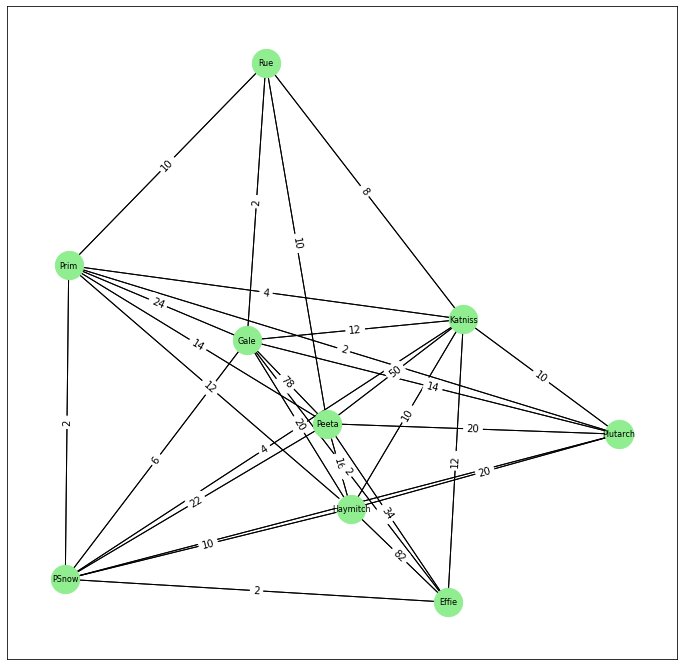

In [14]:
plt.figure(3, figsize=(12,12))
pos = nx.fruchterman_reingold_layout(G)

nx.draw_networkx(G, pos=pos, node_size = 800, font_size=8, node_color="lightgreen")
nx.draw_networkx_edges(G, pos=pos)
edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos=pos, edge_labels=edge_labels)
plt.show()

# Task E

## Degree Distribution

In [15]:
N,K = G.order(), G.size()
avg_deg = float(K)/N
print ("Nodes: ", N)
print ("Edges: ", K)
print ("Average degree: ", avg_deg)


Nodes:  9
Edges:  30
Average degree:  3.3333333333333335


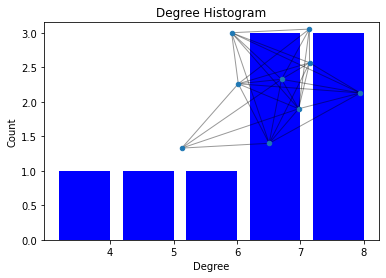

In [16]:
import collections

degree_sequence = sorted([d for n, d in G.degree()], reverse=True)  # degree sequence
# print "Degree sequence", degree_sequence
degreeCount = collections.Counter(degree_sequence)
deg, cnt = zip(*degreeCount.items())

fig, ax = plt.subplots()
plt.bar(deg, cnt, width=0.80, color='b')

plt.title("Degree Histogram")
plt.ylabel("Count")
plt.xlabel("Degree")
ax.set_xticks([d + 0.4 for d in deg])
ax.set_xticklabels(deg)

# draw graph in inset
plt.axes([0.4, 0.4, 0.5, 0.5])
A = (G.subgraph(c) for c in nx.connected_components(G))
Gcc = sorted(A, key=len, reverse=True)[0]
pos = nx.spring_layout(G)
plt.axis('off')
nx.draw_networkx_nodes(G, pos, node_size=20)
nx.draw_networkx_edges(G, pos, alpha=0.4)

plt.show()

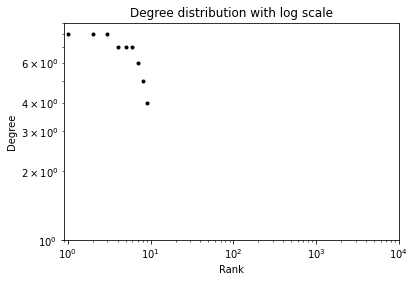

In [17]:
########################################################################
# Degree distribution 
########################################################################

degrees = G.degree()
degree_sequence = sorted([d for n, d in G.degree()], reverse=True)  # degree sequence

# loglog tells matplotlib to use log scales.
# The x values, range(1,10001), are the ranks, 
# and the degree_sequence are the y values.
# The String 'k.' means use black (k) dots (.)
'''
Now we need to do some plotting. Plotting using matplotlib is a lot like 
plotting using MATLAB. Because the degree distribution of a BA graph is a 
power-law, we'd like to use a plot with log scales. Here is how we'd do it.

'''
plt.loglog(range(1,G.order()+1),degree_sequence,'k.')
plt.title("Degree distribution with log scale")
plt.xlabel('Rank')
plt.ylabel('Degree')
plt.ylim(1,max(degree_sequence)+1)
plt.xlim(.9,10001)
plt.savefig("degree_distribution.png")

## Average Shortest Path

In [18]:
C=nx.path_graph(5)

In [19]:
print(nx.average_shortest_path_length(C))

2.0


## Largest Component 

In [20]:
largest = max(nx.connected_components(G), key=len)
len(largest)

9

## Comparing against random graph models

In [21]:
nodes=G.number_of_nodes()
nodes

9

In [22]:
#calculate average degree to use with random graph models 

degree_list = list(nx.degree(G))
#print(degree_list)
no_nodes=len(degree_list)
total_degree=0
for node in degree_list[:5]:
    print("Node ", node[0], " : Degree is ", node[1])
    total_degree=total_degree+ node[1]
avg_degree= total_degree/no_nodes
avg_degree

Node  Katniss  : Degree is  8
Node  Peeta  : Degree is  8
Node  Rue  : Degree is  4
Node  Effie  : Degree is  5
Node  Haymitch  : Degree is  7


3.5555555555555554

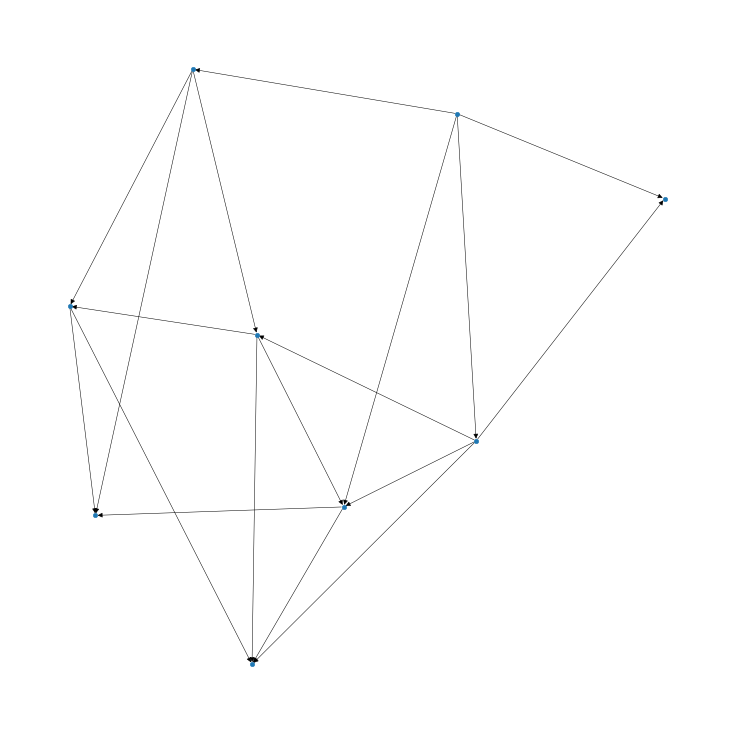

In [23]:
p=avg_degree/(no_nodes-1)
#G2 = nx.erdos_renyi_graph(no_nodes,p)  # same call 
G2 = nx.gnp_random_graph(no_nodes,p)
fig = plt.figure(figsize =(10 ,10))
nx.draw(G2, with_labels = False, node_size = 20, linewidths = 0.5, width = 0.5, arrows=True)
plt.show()


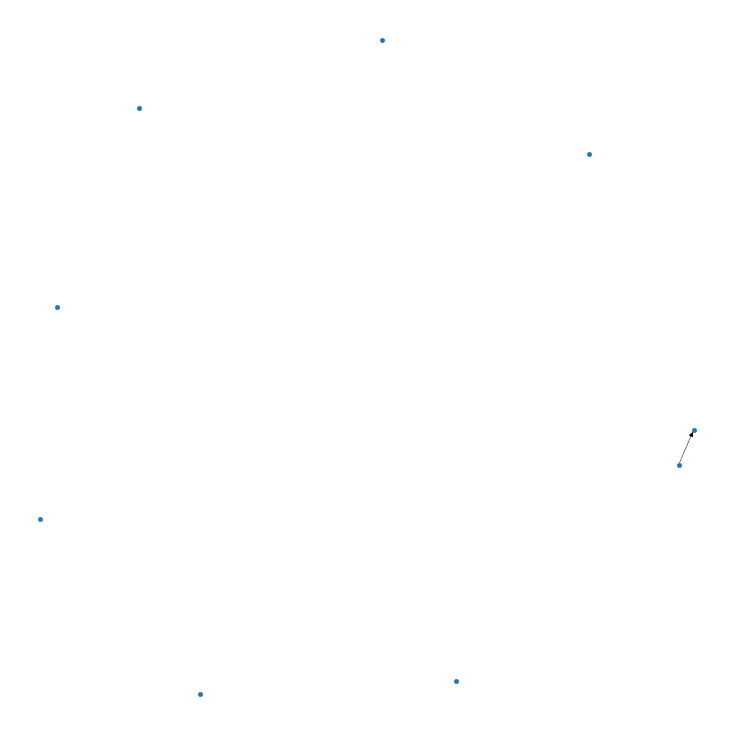

In [24]:
#Make random graph 
G2 = nx.gnp_random_graph(no_nodes,0.1)
#assuming probability for node creation 0.1 
fig = plt.figure(figsize =(10 ,10))
nx.draw(G2, with_labels = False, node_size = 20, linewidths = 0.5, width = 0.5, arrows=True)
plt.show()


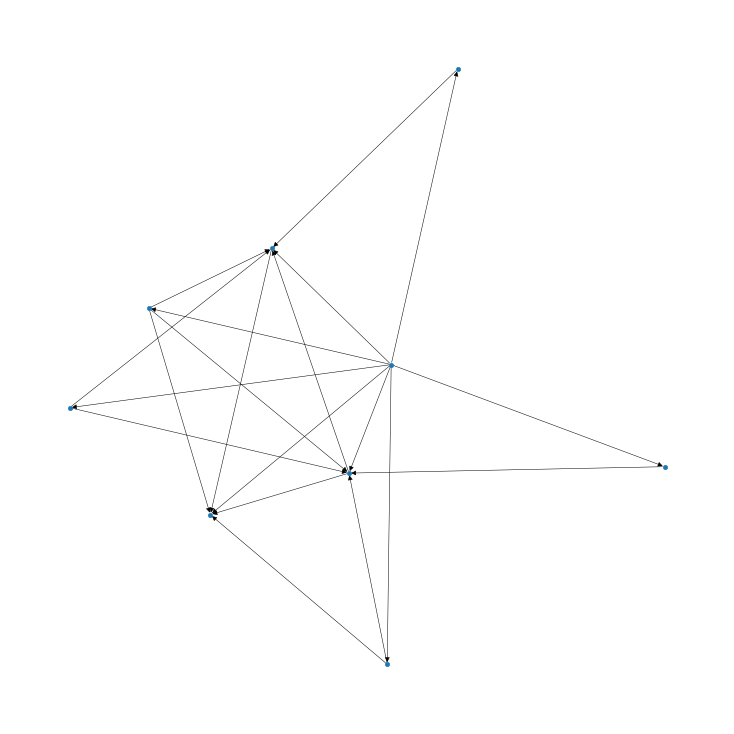

In [25]:
neighbours=5
H = nx.barabasi_albert_graph(no_nodes,neighbours)
fig = plt.figure(figsize =(10 ,10))
nx.draw(H, with_labels = False, node_size = 20, linewidths = 0.5, width = 0.5,arrows=True)
plt.show()

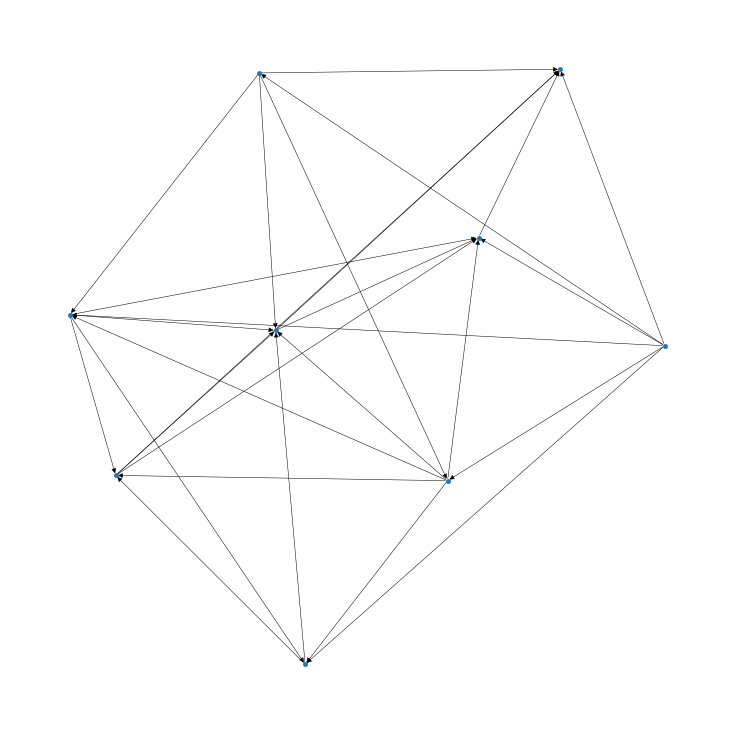

In [26]:
H = nx.newman_watts_strogatz_graph(no_nodes,neighbours,p)
fig = plt.figure(figsize =(10 ,10))

nx.draw(H, with_labels = False, node_size = 20, linewidths = 0.5, width = 0.5,arrows=True)
plt.show()